<a href="https://colab.research.google.com/github/ReynardGhazyTsaqif/SpeechProcessing/blob/main/2311532014_ReynardGhazyTsaqif_Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os



In [2]:
# 2. Link RAW audio dari GitHub Anda
audio_url = "https://raw.githubusercontent.com/ReynardGhazyTsaqif/SpeechProcessing/main/2311532014-ReynardGhazyTsaqif-audio.wav"
filename = "2311532014-ReynardGhazyTsaqif-audio.wav"

# 3. Proses Mendownload file
print(f"Mencoba mendownload {filename}...")
if not os.path.exists(filename):
    try:
        r = requests.get(audio_url, allow_redirects=True)
        r.raise_for_status() # Pastikan download berhasil (kode 200)
        with open(filename, 'wb') as f:
            f.write(r.content)
        print(f"Berhasil mendownload {filename}. Siap untuk dianalisis.")
    except Exception as e:
        print(f"Gagal mendownload. Error: {e}")
else:
    print(f"File {filename} sudah ada di folder aktif.")

Mencoba mendownload 2311532014-ReynardGhazyTsaqif-audio.wav...
File 2311532014-ReynardGhazyTsaqif-audio.wav sudah ada di folder aktif.


## **WAVEFORM**


Memuat audio ke Python...
Audio berhasil dimuat.
Sampling Rate (SR): 48000 Hz
Total Sampel Data: 3992640
Durasi Audio: 83.18 detik


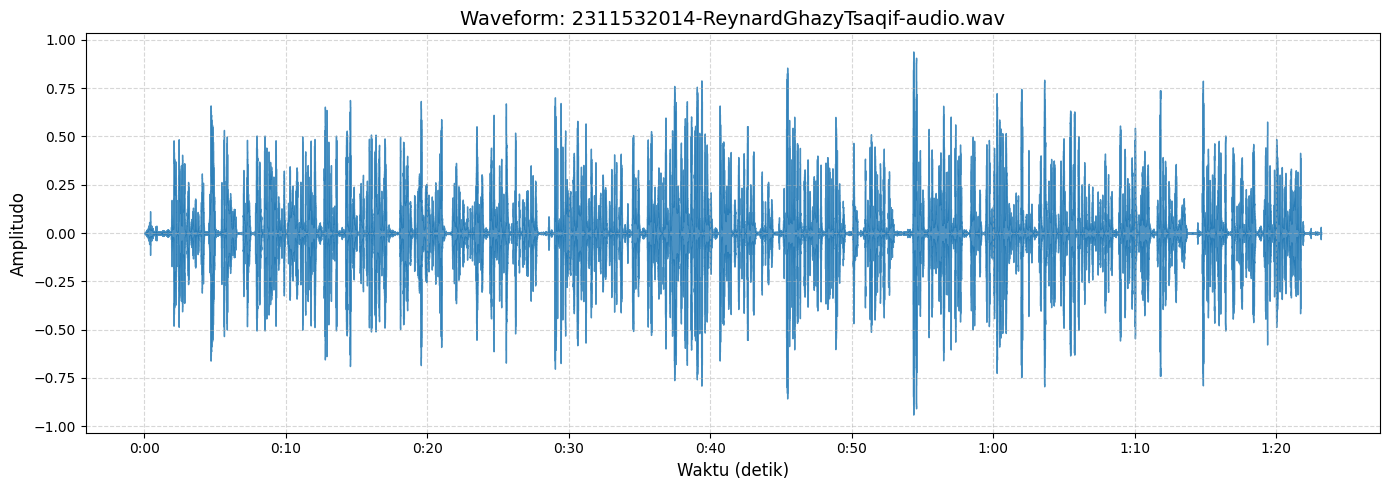

In [3]:
# --- Poin 2: Visualisasi Waveform ---

# 1. Load Audio
# 'sr=None' memastikan kita menggunakan sampling rate asli dari rekaman Anda.
# 'y' adalah data sinyal (array angka), 'sr' adalah sampling rate-nya.
print("\nMemuat audio ke Python...")
y, sr = librosa.load(filename, sr=None)

# Menampilkan informasi dasar audio (untuk referensi laporan)
durasi = librosa.get_duration(y=y, sr=sr)
print(f"Audio berhasil dimuat.")
print(f"Sampling Rate (SR): {sr} Hz")
print(f"Total Sampel Data: {len(y)}")
print(f"Durasi Audio: {durasi:.2f} detik")

# 2. Membuat Plot Waveform
plt.figure(figsize=(14, 5)) # Mengatur ukuran gambar

# Librosa memiliki fungsi visualisasi bawaan yang sangat bagus
librosa.display.waveshow(y, sr=sr, alpha=0.8)

# Memberikan label dan judul
plt.title(f'Waveform: {filename}', fontsize=14)
plt.xlabel('Waktu (detik)', fontsize=12)
plt.ylabel('Amplitudo', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5) # Menambahkan grid agar mudah dianalisa

# Menampilkan grafik
plt.tight_layout()
plt.show()

## **Spectrogram**

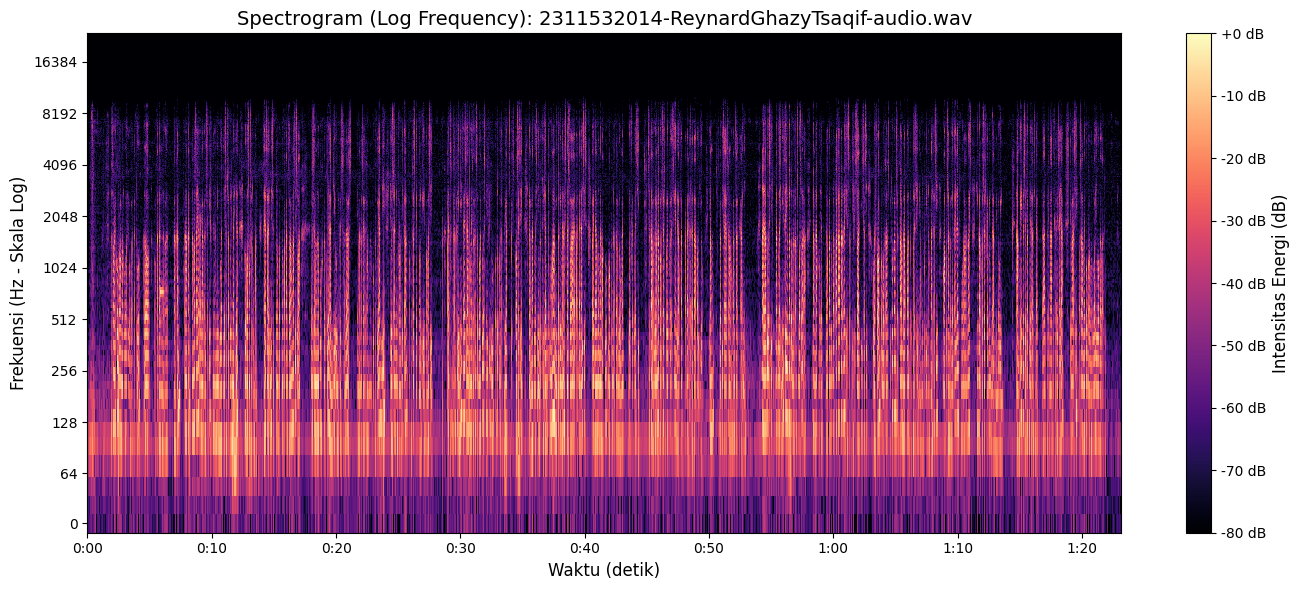

In [4]:
# --- Poin 3: Membuat Spectrogram ---

# 1. Menghitung Short-Time Fourier Transform (STFT)
# Kita mengubah sinyal domain waktu (y) menjadi domain frekuensi (D).
# Secara default librosa menggunakan n_fft=2048
D = librosa.stft(y)

# 2. Mengubah nilai kompleks STFT menjadi amplitudo absolut
# Kemudian ubah ke skala desibel (dB) agar lebih mudah dilihat mata manusia.
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

# 3. Membuat Plot Spectrogram
plt.figure(figsize=(14, 6))

# Tampilkan spectrogram. x-axis adalah waktu, y-axis adalah frekuensi (skala logaritmik seringkali lebih baik untuk suara)
# Anda bisa mengubah y_axis ke 'linear' jika ingin, tapi 'log' lebih natural untuk pendengaran.
img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log')

# Menambahkan Colorbar (Legenda warna)
colorbar = plt.colorbar(img, format="%+2.0f dB")
colorbar.set_label('Intensitas Energi (dB)', fontsize=12)

# Memberikan label dan judul
plt.title(f'Spectrogram (Log Frequency): {filename}', fontsize=14)
plt.xlabel('Waktu (detik)', fontsize=12)
plt.ylabel('Frekuensi (Hz - Skala Log)', fontsize=12)

# Menampilkan grafik
plt.tight_layout()
plt.show()

## **Preprocessing**

### **Normalization**

In [5]:
# Normalisasi menggunakan librosa
y_norm = librosa.util.normalize(y)

# Simpan untuk perbandingan
import soundfile as sf
sf.write('2311532014-Reynard-norm.wav', y_norm, sr)

print("Normalization selesai: Amplitudo kini berada di rentang [-1, 1]")

Normalization selesai: Amplitudo kini berada di rentang [-1, 1]


### **Silence Removal**

In [6]:
# 'top_db' adalah ambang batas (threshold) dalam desibel.
# Jika di bawah 20-30dB, dianggap silence.
y_trimmed, index = librosa.effects.trim(y_norm, top_db=25)

print(f"Silence Removal selesai.")
print(f"Durasi asli: {len(y_norm)/sr:.2f}s | Durasi setelah trim: {len(y_trimmed)/sr:.2f}s")

Silence Removal selesai.
Durasi asli: 83.18s | Durasi setelah trim: 81.65s


### **Noise Reduction**

In [7]:
import scipy.signal

# Menggunakan filter High-pass sederhana untuk membuang noise frekuensi sangat rendah (< 100Hz)
# Atau Anda bisa menggunakan library noisereduce jika diizinkan
b, a = scipy.signal.butter(4, 100/(sr/2), btype='highpass')
y_denoised = scipy.signal.filtfilt(b, a, y_trimmed)

print("Noise Reduction selesai (High-pass filter > 100Hz diterapkan)")

Noise Reduction selesai (High-pass filter > 100Hz diterapkan)


In [8]:
sf.write('2311532014-ReynardGhazyTsaqif-preprocessing.wav', y_denoised, sr)
print("File preprocessing berhasil disimpan!")

File preprocessing berhasil disimpan!


### **Framing & Windowing**

In [9]:
import numpy as np
import soundfile as sf
import librosa
import os

# --- STEP 4d & 4e: Framing & Windowing ---

# Parameter standar speech processing
frame_length = int(0.025 * sr)  # 25 ms
hop_length = int(0.010 * sr)    # 10 ms (overlap)

# Proses Framing
frames_raw = librosa.util.frame(y_denoised, frame_length=frame_length, hop_length=hop_length)

# Windowing (Hamming)
window_function = np.hamming(frame_length)

# Menampilkan jumlah total frame
total_frames = frames_raw.shape[1]
print(f"Total frame yang dihasilkan: {total_frames}")

# Ambil beberapa sampel frame untuk disimpan
num_samples_to_save = 10
indices = np.linspace(0, total_frames - 1, num_samples_to_save).astype(int)

print(f"Menyimpan {num_samples_to_save} sampel frame hasil windowing...")

for i, idx in enumerate(indices):
    # Ambil satu frame
    single_frame = frames_raw[:, idx]

    # Terapkan windowing
    windowed_frame = single_frame * window_function

    # Simpan sebagai file .wav
    out_name = f"2311532014-ReynardGhazyTsaqif-windowing-{i+1}.wav"
    sf.write(out_name, windowed_frame, sr)

    print(f"Berhasil menyimpan: {out_name}")

print("\nProses framing & windowing selesai.")

Total frame yang dihasilkan: 8163
Menyimpan 10 sampel frame hasil windowing...
Berhasil menyimpan: 2311532014-ReynardGhazyTsaqif-windowing-1.wav
Berhasil menyimpan: 2311532014-ReynardGhazyTsaqif-windowing-2.wav
Berhasil menyimpan: 2311532014-ReynardGhazyTsaqif-windowing-3.wav
Berhasil menyimpan: 2311532014-ReynardGhazyTsaqif-windowing-4.wav
Berhasil menyimpan: 2311532014-ReynardGhazyTsaqif-windowing-5.wav
Berhasil menyimpan: 2311532014-ReynardGhazyTsaqif-windowing-6.wav
Berhasil menyimpan: 2311532014-ReynardGhazyTsaqif-windowing-7.wav
Berhasil menyimpan: 2311532014-ReynardGhazyTsaqif-windowing-8.wav
Berhasil menyimpan: 2311532014-ReynardGhazyTsaqif-windowing-9.wav
Berhasil menyimpan: 2311532014-ReynardGhazyTsaqif-windowing-10.wav

Proses framing & windowing selesai.


## **Perbandingan**

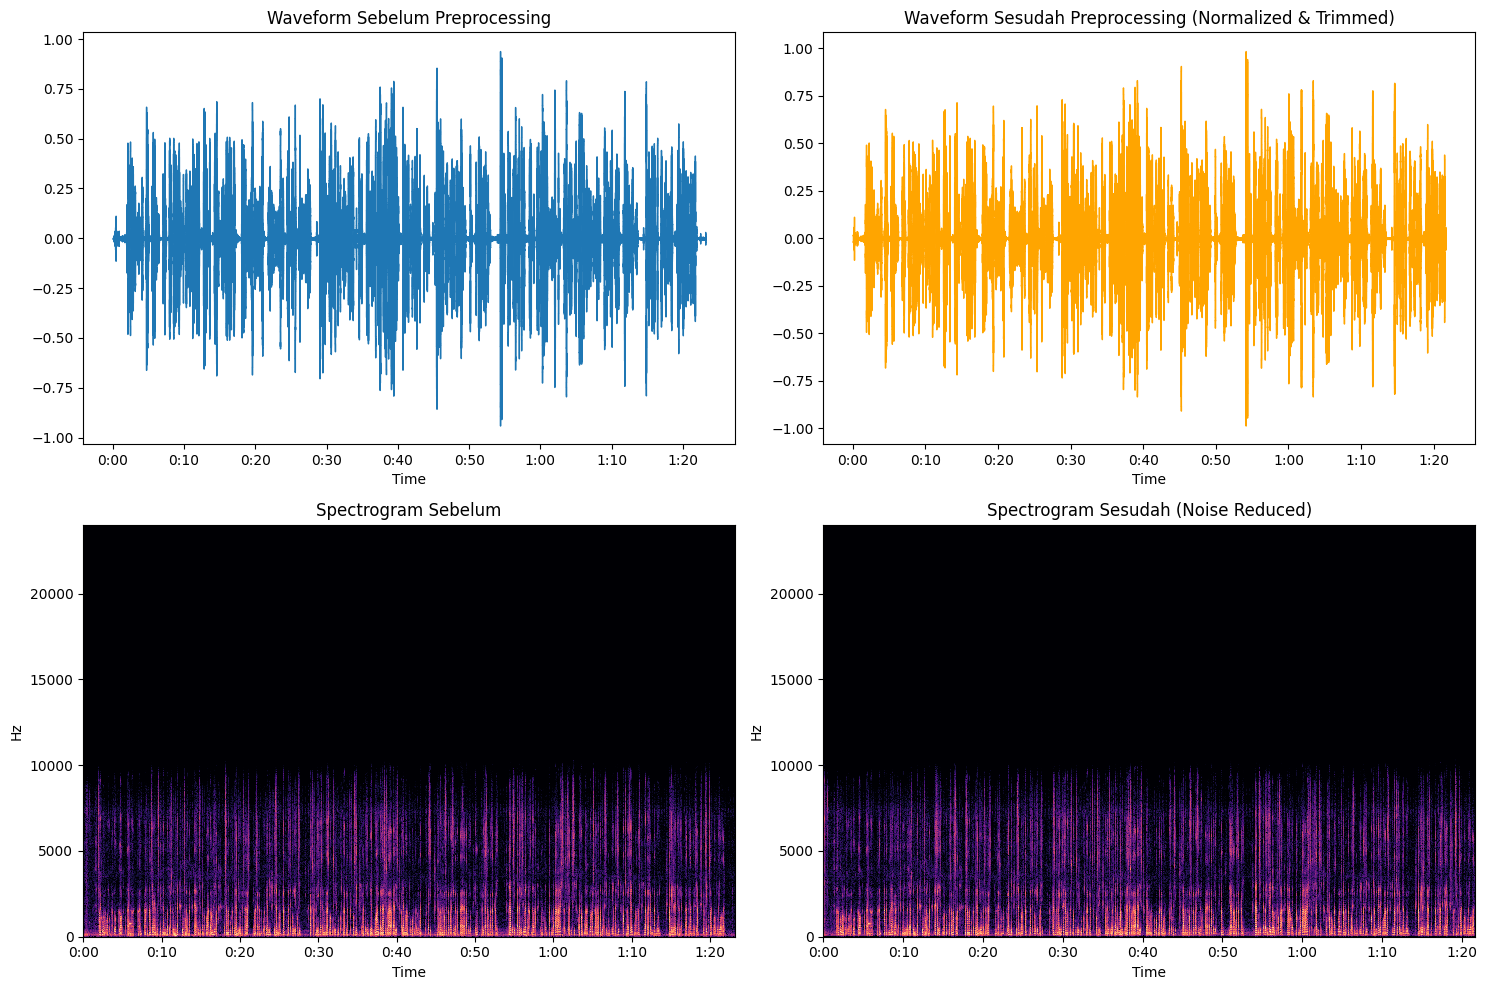

In [10]:
# --- Poin 5: Perbandingan Analisis ---

plt.figure(figsize=(15, 10))

# Waveform Sebelum Preprocessing
plt.subplot(2, 2, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform Sebelum Preprocessing")

# Waveform Sesudah Preprocessing
plt.subplot(2, 2, 2)
librosa.display.waveshow(y_denoised, sr=sr, color='orange')
plt.title("Waveform Sesudah Preprocessing (Normalized & Trimmed)")

# Spectrogram Sebelum
plt.subplot(2, 2, 3)
S_old = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
librosa.display.specshow(S_old, sr=sr, x_axis='time', y_axis='hz')
plt.title("Spectrogram Sebelum")

# Spectrogram Sesudah
plt.subplot(2, 2, 4)
S_new = librosa.amplitude_to_db(np.abs(librosa.stft(y_denoised)), ref=np.max)
librosa.display.specshow(S_new, sr=sr, x_axis='time', y_axis='hz')
plt.title("Spectrogram Sesudah (Noise Reduced)")

plt.tight_layout()
plt.show()

In [11]:
print("Sebelum:", len(y))
print("Sesudah:", len(y_denoised))

Sebelum: 3992640
Sesudah: 3919360


===== PERBANDINGAN SEBELUM & SESUDAH PREPROCESSING =====

[INFO AUDIO]
Jumlah sampel sebelum: 3992640
Jumlah sampel sesudah: 3919360
Durasi sebelum: 83.18 detik
Durasi sesudah: 81.65333333333334 detik


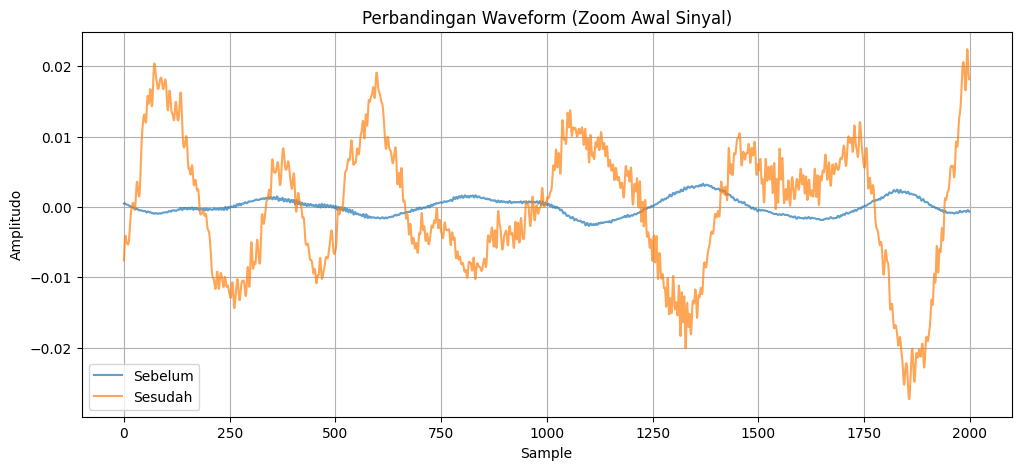

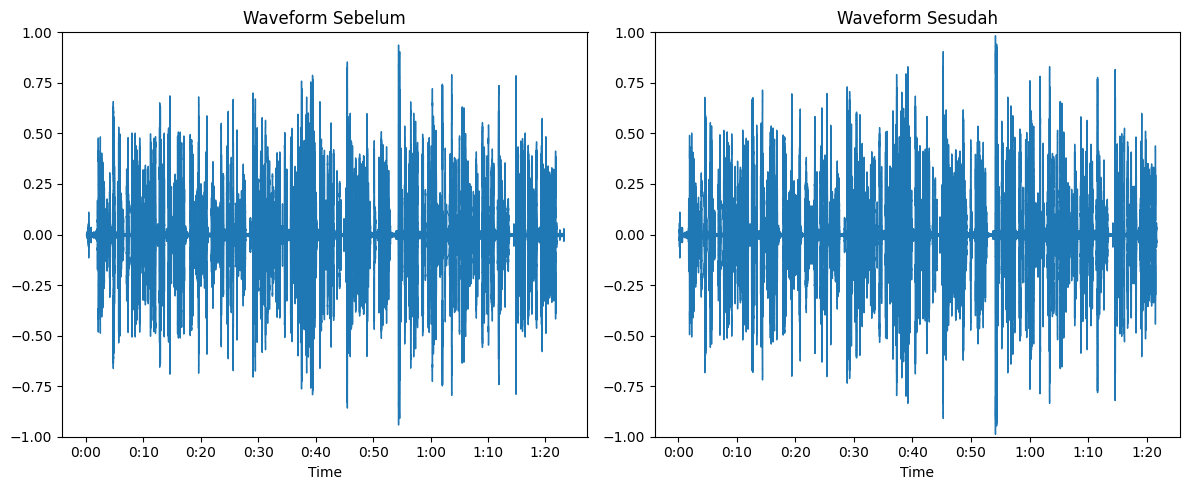

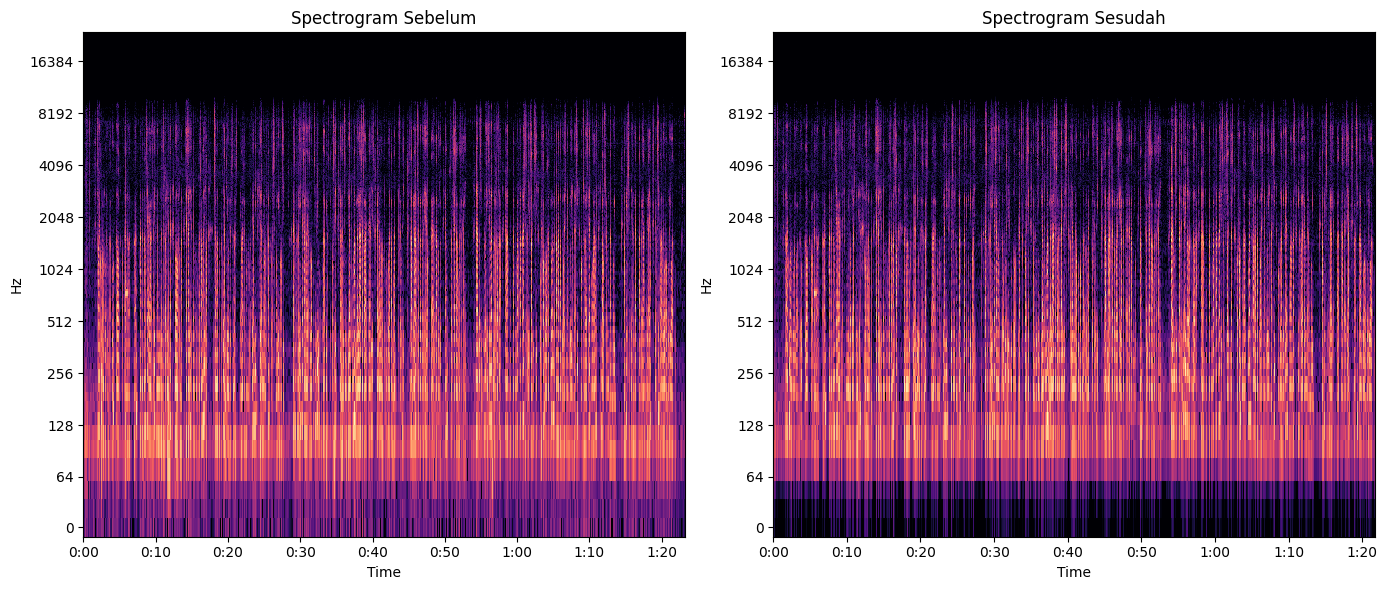

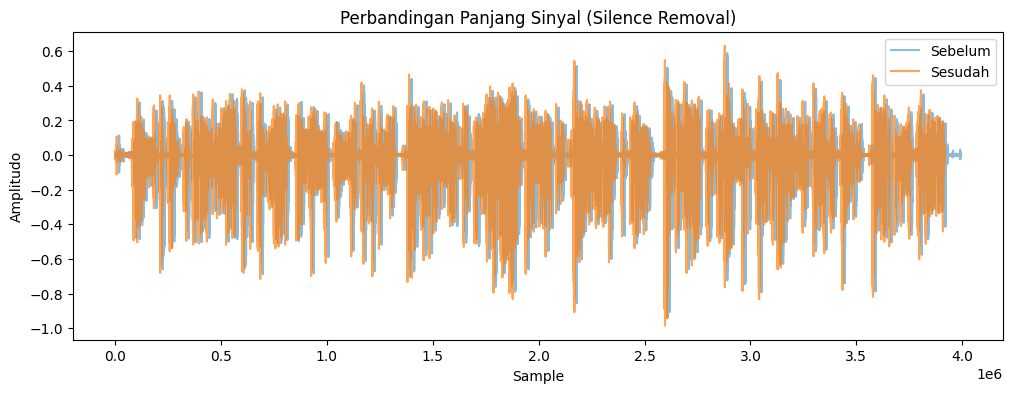


===== ANALISIS SELESAI =====


In [12]:
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np

print("===== PERBANDINGAN SEBELUM & SESUDAH PREPROCESSING =====")

# ===============================
# 1. Informasi dasar audio
# ===============================
print("\n[INFO AUDIO]")
print("Jumlah sampel sebelum:", len(y))
print("Jumlah sampel sesudah:", len(y_denoised))
print("Durasi sebelum:", len(y)/sr, "detik")
print("Durasi sesudah:", len(y_denoised)/sr, "detik")

# ===============================
# 2. Zoom Waveform (biar beda kelihatan)
# ===============================
plt.figure(figsize=(12,5))

plt.plot(y[:2000], label='Sebelum', alpha=0.7)
plt.plot(y_denoised[:2000], label='Sesudah', alpha=0.7)

plt.title("Perbandingan Waveform (Zoom Awal Sinyal)")
plt.xlabel("Sample")
plt.ylabel("Amplitudo")
plt.legend()
plt.grid(True)

plt.show()

# ===============================
# 3. Waveform dengan skala sama
# ===============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform Sebelum")
plt.ylim(-1, 1)

plt.subplot(1,2,2)
librosa.display.waveshow(y_denoised, sr=sr)
plt.title("Waveform Sesudah")
plt.ylim(-1, 1)

plt.tight_layout()
plt.show()

# ===============================
# 4. Spectrogram comparison
# ===============================
plt.figure(figsize=(14,6))

# Sebelum
plt.subplot(1,2,1)
S_old = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
librosa.display.specshow(S_old, sr=sr, x_axis='time', y_axis='log')
plt.title("Spectrogram Sebelum")

# Sesudah
plt.subplot(1,2,2)
S_new = librosa.amplitude_to_db(np.abs(librosa.stft(y_denoised)), ref=np.max)
librosa.display.specshow(S_new, sr=sr, x_axis='time', y_axis='log')
plt.title("Spectrogram Sesudah")

plt.tight_layout()
plt.show()

# ===============================
# 5. Visualisasi perubahan panjang (silence removal)
# ===============================
plt.figure(figsize=(12,4))

plt.plot(y, label="Sebelum", alpha=0.5)
plt.plot(y_denoised, label="Sesudah", alpha=0.7)

plt.title("Perbandingan Panjang Sinyal (Silence Removal)")
plt.xlabel("Sample")
plt.ylabel("Amplitudo")
plt.legend()

plt.show()

print("\n===== ANALISIS SELESAI =====")